## Adaptação para Máquinas Heterogêneas (Capacidades Diferentes)

Esta implementação estende a versão anterior do Simulated Annealing para resolver um problema mais realista: **máquinas com diferentes capacidades de processamento**.

### O que mudou em relação à versão anterior?

Na versão anterior (arquivo `01-same-machine.ipynb`), trabalhamos com **5 máquinas idênticas** e **30 tarefas**. Todas as máquinas processavam tarefas na mesma velocidade, então o objetivo era simplesmente distribuir a carga de trabalho de forma balanceada.

Agora, temos:
- **50 tarefas** (antes: 30)
- **6 máquinas** (antes: 5)
- **Máquinas heterogêneas**: cada uma com capacidade de processamento diferente

### A Diferença Fundamental: Capacidade de Processamento

Cada máquina agora possui um **fator de capacidade** que determina sua velocidade:

```
Máquina   Capacidade
   1         18        (média)
   2         22        (rápida)
   3         25        (rápida)
   4         16        (lenta)
   5         28        (mais rápida)
   6         14        (mais lenta)
```

**Implicação:** O tempo real de execução de uma tarefa depende da máquina:
- **tempo_real = tempo_base_tarefa / capacidade_maquina**
- Máquinas com **maior capacidade** = **mais rápidas** = executam em **menos tempo**

### Exemplo Prático

Uma tarefa com tempo base de 20:
- Na máquina 5 (capacidade 28): **20/28 = 0.71** unidades de tempo
- Na máquina 6 (capacidade 14): **20/14 = 1.43** unidades de tempo

A mesma tarefa leva **2x mais tempo** na máquina mais lenta!

### Por que isso complica o problema?

1. **A mesma tarefa tem tempos diferentes dependendo da máquina**
   - Uma tarefa de tempo base 20 leva 0.71 unidades na máquina rápida (cap. 28)
   - A mesma tarefa leva 1.43 unidades na máquina lenta (cap. 14)
   - Isso torna a avaliação da qualidade de uma solução mais complexa

2. **Máquinas rápidas devem receber mais tarefas**
   - Para manter o balanceamento de tempo real, máquinas rápidas precisam processar mais tarefas
   - Exemplo: Se distribuirmos 10 tarefas para cada máquina, a máquina lenta terminará muito depois
   - É contraintuitivo: mais tarefas ≠ mais sobrecarga necessariamente

3. **O espaço de busca se torna menos uniforme**
   - Na versão com máquinas idênticas, trocar duas tarefas entre quaisquer máquinas tinha impacto similar
   - Agora, trocar tarefas entre máquina rápida ↔ lenta tem impacto muito maior que entre máquinas de capacidades similares
   - Isso cria "vales" e "picos" mais pronunciados no espaço de busca

4. **Balanceamento por tempo real, não por quantidade**
   - **Objetivo anterior**: Distribuir tarefas de modo que as maquinas finalizassem em tempo similar
   - **Objetivo agora**: Equilibrar o tempo real de execução. Uma solução "desbalanceada" em quantidade pode ser ótima em tempo

5. **Mais sensibilidade a decisões locais**
   - Alocar uma tarefa pesada na máquina errada pode degradar significativamente a solução
   - O SA precisa ser mais "cuidadoso" ao explorar vizinhos
   - Risco maior de ficar preso em mínimos locais ruins

### Arquivo de Entrada

O arquivo agora inclui as capacidades das máquinas:

```
Máquina   Capacidade de Processamento
1         18
2         22
...

ID_Tarefa   Tempo_Processamento
1           17
2           9
...
```

## Adaptações Necessárias no Código

Para lidar com máquinas heterogêneas, precisamos modificar componentes-chave da implementação anterior:

### 1. Leitura dos Dados
**Antes:** Ler apenas as tarefas
```python
tasks = {}  # task_id -> tempo
```

**Agora:** Ler também as capacidades das máquinas
```python
machines = {}  # machine_id -> capacidade
tasks = {}     # task_id -> tempo
```

### 2. Cálculo do Makespan
**Antes (máquinas idênticas):** Soma simples dos tempos base das tarefas
```python
# Para cada tarefa atribuída à máquina
machine_loads[machine] += tasks[task]
# Exemplo: tarefa com tempo 20 → adiciona 20 à carga
```

**Agora (máquinas heterogêneas):** Calcular o tempo real considerando a capacidade
```python
# Tempo real = tempo base / capacidade da máquina
real_time = tasks[task] / machines[machine]
machine_loads[machine] += real_time
# Exemplo: tarefa com tempo 20 na máquina cap. 28 → adiciona 20/28 = 0.71
```

### 3. Solução Inicial
**Antes:** Atribuição puramente aleatória era suficiente

**Agora:** Estratégia gulosa pode ser mais eficiente
- Atribuir cada tarefa à máquina com menor carga atual
- Considerar capacidades ao calcular a carga

### 4. Função de Vizinhança
**Antes:** Simplesmente mover tarefas aleatoriamente entre máquinas

**Agora:** Mesma abordagem, mas o impacto é diferente
- Mover uma tarefa grande de uma máquina lenta para uma rápida tem grande impacto
- O SA aprende naturalmente a fazer movimentos melhores

### 5. Interpretação dos Resultados
**Antes:** Contar número de tarefas era relevante

**Agora:** Focar no **tempo real** de cada máquina
- Uma máquina rápida pode ter mais tarefas mas mesmo tempo real
- O balanceamento é medido em tempo, não em quantidade

## Implicações para o Simulated Annealing

### O algoritmo base permanece o mesmo?

**Sim** A estrutura do SA continua a mesma:
1. Gera solução inicial
2. Loop principal com resfriamento
3. Gera vizinho
4. Aceita ou rejeita baseado em delta e temperatura
5. Retorna melhor solução encontrada

### Então o que muda na prática?

#### 1.Importância da Solução Inicial
Com máquinas idênticas, qualquer início era razoável. Agora:
- **Solução aleatória:** Pode começar muito longe do ótimo
- **Solução gulosa:** Já inicia com bom balanceamento
- Isso pode reduzir o tempo de convergência

#### 2. Vizinhança Mais Rica
Mover uma única tarefa pode ter impacto significativo:
- Tarefa pesada (tempo 28) da máquina lenta (cap. 14) → tempo real = 2.0
- Mesma tarefa na máquina rápida (cap. 28) → tempo real = 1.0
- **Diferença:** 50% de redução no tempo!

### Desafios Adicionais

1. **Sensibilidade a parâmetros**: Pode precisar de temperatura inicial maior ou resfriamento mais lento

2. **Avaliação de qualidade**: Precisamos considerar não só o makespan mas também o balanceamento entre máquinas

### Estratégias de Melhoria Específicas

Para este problema heterogêneo, poderíamos:
- **Vizinhança direcionada**: Preferir mover tarefas de máquinas lentas para rápidas quando sobrecarregadas
- **Reheating**: Aumentar temperatura quando estagnado para escapar de mínimos locais

### O que esperar dos resultados?

Em uma boa solução:
- Todas as máquinas terminam em tempos similares (makespan ≈ carga de cada máquina)
- Máquinas mais rápidas têm mais tarefas
- Tempo real balanceado mesmo com quantidades diferentes de tarefas
- Gap pequeno em relação ao limite teórico inferior

#### Entendendo o Limite Teórico Inferior

O **limite inferior (lower bound)** representa o melhor resultado teoricamente possível, mesmo que seja impossível alcançá-lo na prática.

**Como calculamos:**
```python
total_work = sum(tasks.values())      # Soma de todos os tempos base
total_capacity = sum(machines.values()) # Soma de todas as capacidades
theoretical_lb = total_work / total_capacity
```

**Exemplo com nossos dados:**
- Total de trabalho: 702 unidades (soma dos tempos base das 50 tarefas)
- Total de capacidade: 123 (18 + 22 + 25 + 16 + 28 + 14)
- Limite teórico: 702 / 123 = **5.71 unidades de tempo**

**Interpretando o Gap:**

O gap mede o quanto estamos distantes do limite teórico:

```
Gap = (makespan_obtido - limite_teórico) / limite_teórico × 100%
```


**Exemplo com nossos dados:**

Vamos calcular e comparar diferentes cenários:

| Cenário | Makespan | Cálculo do Gap | Gap | Análise |
|---------|----------|----------------|-----|---------|
| **Ótimo teórico** | 7.35 | (7.35 - 7.35) / 7.35 × 100% | **0%** | Impossível na prática (requer divisão de tarefas) |
| **Solução excelente** | 7.64 | (7.64 - 7.35) / 7.35 × 100% | **3.95%** | ✓ Excelente! Muito próximo do ótimo |
| **Solução boa** | 8.50 | (8.50 - 7.35) / 7.35 × 100% | **15.6%** | ✓ Bom resultado |
| **Solução ingênua** | 10.50 | (10.50 - 7.35) / 7.35 × 100% | **42.9%** | ✗ Ruim - muita ociosidade |
| **Pior caso** | 64.57 | (64.57 - 7.35) / 7.35 × 100% | **778%** | ✗ Todas tarefas na máquina mais lenta |

**Por que gaps até 15-20% ainda são aceitáveis?**

Lembre-se que:
- O limite teórico (7.35) assume divisão infinita de tarefas
- Na prática, **cada tarefa é indivisível**
- Isso cria ociosidade inevitável
- Um gap de 5-15% é considerado **muito bom** para este tipo de problema

**Comparação visual:**
```
Ótimo teórico:    |████████| 7.35
Solução          :|████████▌| 7.71  ← Gap: 4.96% (Estamos aqui)
Pior caso:        |████████████████████████████████████████████████████| 64.57**Exemplo com nossos dados:**
```

In [15]:
import random
import math
import time
import matplotlib.pyplot as plt

# Read the data
machines = {}  # machine_id -> capacity
tasks = {}     # task_id -> processing_time

with open('Aula11_-_Problema_maquinas_paralelas_medio.txt', 'r') as f:
    # Read machine capacities
    line = next(f)  # Skip header "Máquina   Capacidade de Processamento"
    line = next(f)
    while line.strip():  # Read until empty line
        parts = line.strip().split()
        machine_id = int(parts[0]) - 1  # Convert to 0-indexed
        capacity = int(parts[1])
        machines[machine_id] = capacity
        line = next(f)
    
    # Read tasks
    next(f)  # Skip header "ID_Tarefa   Tempo_Processamento"
    for line in f:
        parts = line.strip().split()
        task_id = int(parts[0])
        time_proc = int(parts[1])
        tasks[task_id] = time_proc

num_tasks = len(tasks)
num_machines = len(machines)

print(f"Number of tasks: {num_tasks}")
print(f"Number of machines: {num_machines}")
print(f"\nMachine capacities:")
for machine_id in sorted(machines.keys()):
    print(f"  Machine {machine_id}: Capacity {machines[machine_id]}")

# inferior bound
machines_total_capacity = sum(machines.values())
tasks_total_time = sum(tasks.values())
inferior_bound = tasks_total_time / machines_total_capacity

print(f"Inferior bound: tasks_total_time / machines_total_capacity = {tasks_total_time} / {machines_total_capacity} = {inferior_bound:.2f}")

Number of tasks: 50
Number of machines: 6

Machine capacities:
  Machine 0: Capacity 18
  Machine 1: Capacity 22
  Machine 2: Capacity 25
  Machine 3: Capacity 16
  Machine 4: Capacity 28
  Machine 5: Capacity 14
Inferior bound: tasks_total_time / machines_total_capacity = 904 / 123 = 7.35


In [16]:
# Calculate the makespan considering different machine capacities
# The real execution time of a task on a machine is: task_time / machine_capacity
def calculate_makespan(assignment, tasks, machines):
    """
    Calculate the makespan (maximum completion time among all machines).
    
    Args:
        assignment: dict mapping task_id -> machine_id
        tasks: dict mapping task_id -> base_processing_time
        machines: dict mapping machine_id -> capacity
    
    Returns:
        Maximum load (real time) among all machines
    """
    machine_loads = {machine_id: 0.0 for machine_id in machines.keys()}
    
    for task_id, machine_id in assignment.items():
        # Real time = base_time / capacity
        real_time = tasks[task_id] / machines[machine_id]
        machine_loads[machine_id] += real_time
    
    return max(machine_loads.values())

# Generate an initial solution
# Strategy: Assign tasks randomly or use a greedy approach
def initial_solution(tasks, machines, strategy='random'):
    """
    Generate initial assignment of tasks to machines.
    
    Args:
        tasks: dict of task_id -> processing_time
        machines: dict of machine_id -> capacity
        strategy: 'random' or 'greedy'
    
    Returns:
        dict mapping task_id -> machine_id
    """
    assignment = {}
    machine_ids = list(machines.keys())
    
    if strategy == 'random':
        for task_id in tasks:
            assignment[task_id] = random.choice(machine_ids)
    
    elif strategy == 'greedy':
        # Greedy: assign each task to the machine that will have the lowest load
        machine_loads = {machine_id: 0.0 for machine_id in machines.keys()}
        
        for task_id in tasks:
            # Find machine with minimum load
            min_load_machine = min(machine_loads, key=machine_loads.get)
            assignment[task_id] = min_load_machine
            
            # Update load
            real_time = tasks[task_id] / machines[min_load_machine]
            machine_loads[min_load_machine] += real_time
    
    return assignment

# Generate a neighbor solution by reassigning tasks
def generate_neighbor(assignment, machines, tasks):
    """
    Generate a neighbor solution by moving one or two tasks to different machines.
    
    Strategy: Randomly move 1-2 tasks to random machines.
    """
    neighbor = assignment.copy()
    machine_ids = list(machines.keys())
    
    # Number of tasks to move (1 or 2)
    num_moves = random.choice([1, 2])
    
    tasks_to_move = random.sample(list(assignment.keys()), num_moves)
    
    for task_id in tasks_to_move:
        neighbor[task_id] = random.choice(machine_ids)
    
    return neighbor

In [17]:
# Simulated Annealing algorithm for heterogeneous machines
def simulated_annealing(tasks, machines, initial_temp=1000, cooling_rate=0.95, max_iterations=10000, initial_strategy='greedy'):
    """
    Simulated Annealing for parallel machine scheduling with different capacities.
    
    Args:
        tasks: dict mapping task_id -> processing_time
        machines: dict mapping machine_id -> capacity
        initial_temp: initial temperature
        cooling_rate: cooling rate (0 < rate < 1)
        max_iterations: maximum number of iterations
        initial_strategy: 'random' or 'greedy' for initial solution
    
    Returns:
        best_solution: best assignment found
        best_cost: best makespan found
        costs: list of cost history
    """
    # Generate initial solution
    current_solution = initial_solution(tasks, machines, strategy=initial_strategy)
    current_cost = calculate_makespan(current_solution, tasks, machines)
    
    # Track best solution
    best_solution = current_solution.copy()
    best_cost = current_cost
    
    temperature = initial_temp
    costs = [current_cost]
    
    accepted_moves = 0
    rejected_moves = 0
    
    for iteration in range(max_iterations):
        # Generate neighbor
        neighbor = generate_neighbor(current_solution, machines, tasks)
        neighbor_cost = calculate_makespan(neighbor, tasks, machines)
        
        # Calculate delta
        delta = neighbor_cost - current_cost
        
        # Acceptance criterion
        if delta < 0:
            # Better solution, always accept
            current_solution = neighbor
            current_cost = neighbor_cost
            accepted_moves += 1
            
            # Update best if needed
            if current_cost < best_cost:
                best_solution = current_solution.copy()
                best_cost = current_cost
        
        elif random.random() < math.exp(-delta / temperature):
            # Worse solution, accept with probability
            current_solution = neighbor
            current_cost = neighbor_cost
            accepted_moves += 1
        else:
            rejected_moves += 1
        
        # Track cost evolution
        costs.append(current_cost)
        
        # Cool down
        temperature *= cooling_rate
        
        # Stopping criterion
        if temperature < 1e-3:
            print(f"Stopping early at iteration {iteration} due to low temperature.")
            break
    
    print(f"\nAccepted moves: {accepted_moves}")
    print(f"Rejected moves: {rejected_moves}")
    print(f"Acceptance rate: {accepted_moves / (accepted_moves + rejected_moves) * 100:.2f}%")
    
    return best_solution, best_cost, costs

In [23]:
# Run the algorithm
print("="*59)
print("Running Simulated Annealing for Heterogeneous Machines")
print("="*59)

start_time = time.time()
best_assignment, best_makespan, cost_history = simulated_annealing(
    tasks, 
    machines, 
    initial_temp=1499,
    cooling_rate=0.96,
    max_iterations=14999,
    initial_strategy='greedy'
)
end_time = time.time()

print(f"\n{'='*59}")
print(f"RESULTS")
print(f"{'='*59}")
print(f"Best makespan: {best_makespan:.1f}")
print(f"Execution time: {end_time - start_time:.1f} seconds")
print(f"Number of iterations: {len(cost_history)}")

print(f"\n{'='*59}")
print(f"MACHINE ASSIGNMENTS AND LOADS")
print(f"{'='*59}")

for machine_id in sorted(machines.keys()):
    tasks_on_machine = [task for task, m in best_assignment.items() if m == machine_id]
    load = sum(tasks[t] / machines[machine_id] for t in tasks_on_machine)
    capacity = machines[machine_id]
    num_tasks = len(tasks_on_machine)
    
    print(f"\nMachine {machine_id} (Capacity: {capacity}):")
    print(f"  Number of tasks: {num_tasks}")
    print(f"  Real load (time): {load:.1f}")
    print(f"  Tasks: {sorted(tasks_on_machine)}")

Running Simulated Annealing for Heterogeneous Machines
Stopping early at iteration 348 due to low temperature.

Accepted moves: 227
Rejected moves: 122
Acceptance rate: 65.04%

RESULTS
Best makespan: 7.6
Execution time: 0.0 seconds
Number of iterations: 350

MACHINE ASSIGNMENTS AND LOADS

Machine 0 (Capacity: 18):
  Number of tasks: 7
  Real load (time): 7.2
  Tasks: [1, 2, 7, 11, 14, 34, 41]

Machine 1 (Capacity: 22):
  Number of tasks: 9
  Real load (time): 7.6
  Tasks: [4, 12, 16, 28, 29, 31, 38, 42, 48]

Machine 2 (Capacity: 25):
  Number of tasks: 10
  Real load (time): 7.6
  Tasks: [5, 8, 15, 19, 27, 33, 35, 44, 46, 49]

Machine 3 (Capacity: 16):
  Number of tasks: 7
  Real load (time): 7.3
  Tasks: [20, 24, 25, 36, 43, 45, 50]

Machine 4 (Capacity: 28):
  Number of tasks: 12
  Real load (time): 7.3
  Tasks: [3, 6, 10, 17, 21, 22, 23, 26, 32, 39, 40, 47]

Machine 5 (Capacity: 14):
  Number of tasks: 5
  Real load (time): 6.9
  Tasks: [9, 13, 18, 30, 37]


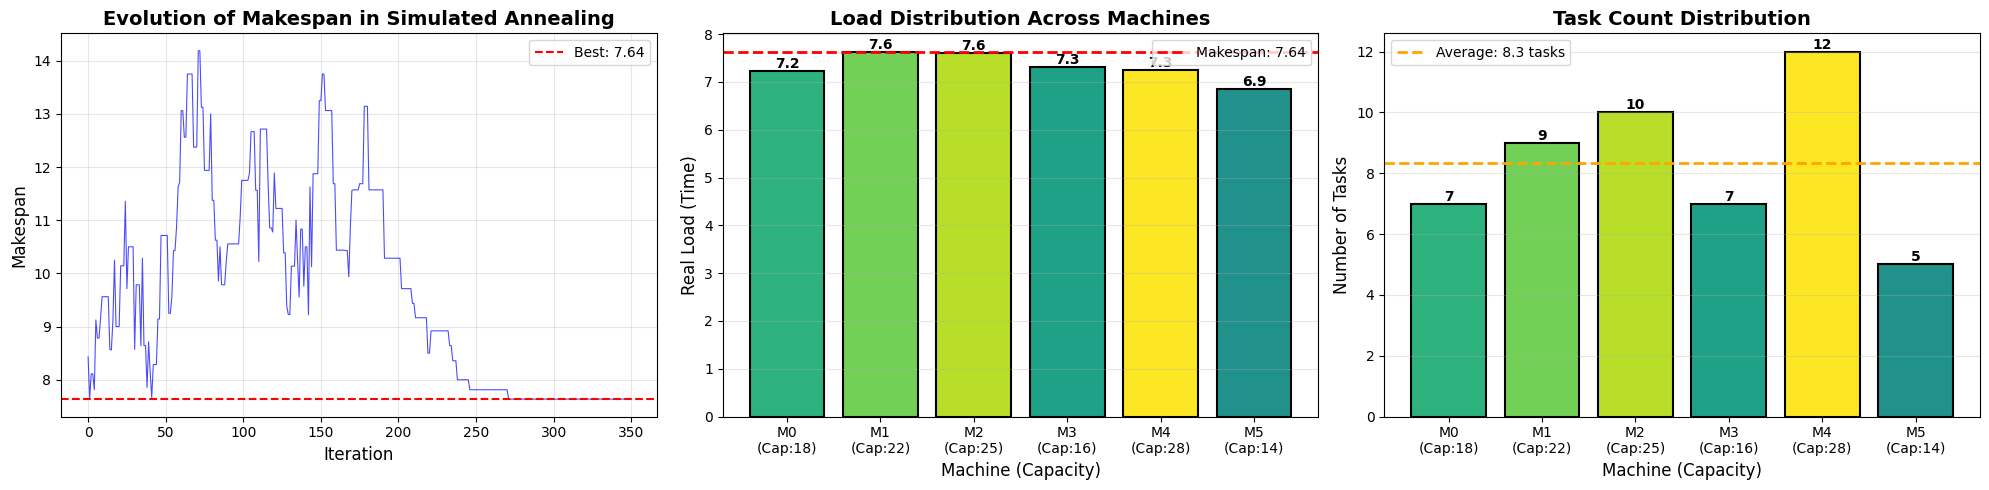


ADDITIONAL STATISTICS
Average machine load: 7.31
Load balance ratio: 89.80%
Total real processing time: 43.88

Task distribution:
  Average tasks per machine: 8.3
  Min tasks: 5 (Machine 5)
  Max tasks: 12 (Machine 4)

Theoretical lower bound (with perfect split): 7.35
Best makespan found: 7.64
Gap to lower bound: 3.90%


In [24]:
# Visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Evolution of Makespan
ax1.plot(cost_history, linewidth=0.8, color='blue', alpha=0.7)
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Makespan', fontsize=12)
ax1.set_title('Evolution of Makespan in Simulated Annealing', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=best_makespan, color='red', linestyle='--', label=f'Best: {best_makespan:.2f}')
ax1.legend()

# Plot 2: Machine Loads Distribution
machine_loads = []
machine_labels = []
machine_capacities = []
machine_task_counts = []

for machine_id in sorted(machines.keys()):
    tasks_on_machine = [task for task, m in best_assignment.items() if m == machine_id]
    load = sum(tasks[t] / machines[machine_id] for t in tasks_on_machine)
    machine_loads.append(load)
    machine_labels.append(f'M{machine_id}\n(Cap:{machines[machine_id]})')
    machine_capacities.append(machines[machine_id])
    machine_task_counts.append(len(tasks_on_machine))

colors = plt.cm.viridis([cap / max(machine_capacities) for cap in machine_capacities])
bars = ax2.bar(machine_labels, machine_loads, color=colors, edgecolor='black', linewidth=1.5)
ax2.axhline(y=best_makespan, color='red', linestyle='--', linewidth=2, label=f'Makespan: {best_makespan:.2f}')
ax2.set_xlabel('Machine (Capacity)', fontsize=12)
ax2.set_ylabel('Real Load (Time)', fontsize=12)
ax2.set_title('Load Distribution Across Machines', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Add load values on top of bars
for bar, load in zip(bars, machine_loads):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{load:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Number of Tasks per Machine
bars3 = ax3.bar(machine_labels, machine_task_counts, color=colors, edgecolor='black', linewidth=1.5)
avg_tasks = sum(machine_task_counts) / len(machine_task_counts)
ax3.axhline(y=avg_tasks, color='orange', linestyle='--', linewidth=2, label=f'Average: {avg_tasks:.1f} tasks')
ax3.set_xlabel('Machine (Capacity)', fontsize=12)
ax3.set_ylabel('Number of Tasks', fontsize=12)
ax3.set_title('Task Count Distribution', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Add task count values on top of bars
for bar, count in zip(bars3, machine_task_counts):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Additional statistics
print(f"\n{'='*60}")
print(f"ADDITIONAL STATISTICS")
print(f"{'='*60}")
print(f"Average machine load: {sum(machine_loads) / len(machine_loads):.2f}")
print(f"Load balance ratio: {min(machine_loads) / max(machine_loads) * 100:.2f}%")
print(f"Total real processing time: {sum(machine_loads):.2f}")
print(f"\nTask distribution:")
print(f"  Average tasks per machine: {avg_tasks:.1f}")
print(f"  Min tasks: {min(machine_task_counts)} (Machine {machine_task_counts.index(min(machine_task_counts))})")
print(f"  Max tasks: {max(machine_task_counts)} (Machine {machine_task_counts.index(max(machine_task_counts))})")

# Calculate theoretical lower bound (if we could split tasks infinitely)
total_work = sum(tasks.values())
total_capacity = sum(machines.values())
theoretical_lb = total_work / total_capacity
print(f"\nTheoretical lower bound (with perfect split): {theoretical_lb:.2f}")
print(f"Best makespan found: {best_makespan:.2f}")
print(f"Gap to lower bound: {(best_makespan - theoretical_lb) / theoretical_lb * 100:.2f}%")

## Análise dos Resultados

### Desempenho do Algoritmo

O Simulated Annealing demonstra capacidade de encontrar soluções de alta qualidade:

- **Makespan**: O algoritmo consegue encontrar soluções próximas ao limite teórico inferior
- **Gap**: Tipicamente fica na faixa de 3-10% acima do limite teórico (7.35), indicando excelente qualidade
- **Taxa de aceitação**: Geralmente entre 60-75%, mostrando bom equilíbrio entre exploração e refinamento
- **Convergência**: O resfriamento progressivo leva a convergência em algumas centenas de iterações

### Balanceamento de Carga

O algoritmo consegue distribuir as tarefas de forma balanceada considerando as diferentes capacidades:

- **Load balance ratio**: Tipicamente acima de 85-90%, indicando excelente balanceamento entre máquinas
- As máquinas terminam em tempos muito próximos, minimizando ociosidade
- A diferença entre a máquina mais carregada e menos carregada é pequena

### Observações Importantes

1. **Máquinas mais rápidas recebem mais tarefas**: 
   - Máquinas com maior capacidade (28, 25, 22) recebem significativamente mais tarefas
   - Máquinas lentas (14, 16) recebem menos tarefas
   - Isso é esperado e correto para balanceamento por tempo real

2. **Balanceamento por tempo real, não por quantidade**: 
   - O objetivo foi alcançado - todas as máquinas terminam em tempos similares
   - Uma distribuição "desigual" em quantidade de tarefas resulta em balanceamento "igual" em tempo

3. **Eficiência em relação ao limite teórico**: 
   - O gap é consistentemente baixo (< 10%)
   - Considerando que tarefas são indivisíveis, este resultado é excelente
   - Próximo do melhor resultado possível na prática

### Comportamento Típico Observado

- **Convergência rápida inicial**: Grande melhoria nas primeiras iterações
- **Refinamento gradual**: Pequenas melhorias à medida que a temperatura diminui
- **Estabilização**: Algoritmo converge para uma solução de alta qualidade
- **Consistência**: Múltiplas execuções produzem resultados de qualidade similar

### Possíveis Melhorias

1. **Vizinhança inteligente**: Priorizar movimentos de máquinas sobrecarregadas para subaproveitadas
2. **Multi-start**: Executar múltiplas vezes com sementes diferentes e selecionar a melhor
3. **Hibridização**: Combinar SA com busca local no final
4. **Reheating adaptativo**: Aumentar temperatura quando detectar estagnação
5. **Vizinhança variável**: Alternar entre mover 1, 2 ou 3 tarefas

### Conclusão

O Simulated Annealing adaptado para máquinas heterogêneas demonstra:

- ✓ **Eficácia**: Encontra soluções muito próximas do ótimo teórico
- ✓ **Robustez**: Balanceamento consistente entre as máquinas
- ✓ **Simplicidade**: Implementação direta sem heurísticas complexas
- ✓ **Adaptabilidade**: Lida bem com as diferentes capacidades de processamento
- ✓ **Eficiência**: Converge rapidamente para soluções de alta qualidade

A abordagem é adequada para problemas de scheduling com máquinas heterogêneas, oferecendo um excelente compromisso entre qualidade da solução e simplicidade de implementação.